In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the course.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.patches as patches
import json, random, copy
from collections import OrderedDict


In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
def seed_everything(seed=42):
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # set to False for deterministic behavior
    # torch.backends.cudnn.enabled = False # can be set to False if needed
    print(f"Random seed set to {seed}")

# Usage:
seed_everything(0)

Random seed set to 0


In [4]:
print(sys.version)
print(torch.__version__)


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.11.0+cpu


In [5]:
# Check the specifications of your machine/what resources you have been allocated through Colab.
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


In [6]:

# cpu or cuda? This code snippet will tell you.
device ='cpu'
if torch.cuda.is_available():
    device='cuda:0'
print(device)


cpu


In [7]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
root_folder = '/content/drive/MyDrive/OIST-mini-course'
!ls $root_folder

cls_train.pkl		    dataset_for_classification
cls_val.pkl		    dataset_for_classification.zip
code001_setup_part-A.ipynb  dataset_for_detection
code001_setup_part-B.ipynb  dataset_for_detection.zip
code001_setup_readme.pdf    det_trainval_splits.pkl
code002_data_prep_NN.ipynb  meta_detection.pkl
code003_LogReg.ipynb	    test-image.jpg
code004_DNN_scratch.ipynb   test-image-sharpened.jpg


# Split the dataset into a training set and a validation set at slices level

In [9]:
# save this split for training and evaluation the model we will develop later
filename = os.path.join(root_folder, 'meta_detection.pkl')
with open(filename, 'rb') as file:
    datasetInfo = pickle.load(file)

train_imgList = datasetInfo['train_imgList']
train_maskList = datasetInfo['train_maskList']
valid_imgList = datasetInfo['valid_imgList']
valid_maskList = datasetInfo['valid_maskList']

In [10]:
train_imgList[0], train_maskList[0]

('/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/42784x_52480y/3z.jpg',
 [])

In [11]:
train_imgList_cleanup = []
train_maskList_cleanup = []
valid_imgList_cleanup = []
valid_maskList_cleanup = []

for i in range(len(train_imgList)):
    if len(train_maskList[i])!=0 and [] not in train_maskList[i]:
        train_imgList_cleanup += [os.path.join(root_folder, train_imgList[i])]
        train_maskList_cleanup += [train_maskList[i]]
    else:
        print(train_imgList[i])

/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/42784x_52480y/3z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/45568x_53520y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/58096x_56640y/4z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/40000x_54560y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/49744x_45200y/3z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/48352x_58720y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/48352x_58720y/6z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/49744x_46240y/4z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/40000x_56640y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/58096x_41040y/3z.jpg


In [12]:
for i in range(len(valid_imgList)):
    if len(valid_maskList[i])!=0  and [] not in valid_maskList[i]:
        valid_imgList_cleanup += [os.path.join(root_folder, valid_imgList[i])]
        valid_maskList_cleanup += [valid_maskList[i]]
    else:
        print(valid_imgList[i])

/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/45568x_42080y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/49744x_54560y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/49744x_58720y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/51136x_54560y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/59488x_43120y/5z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/59488x_43120y/3z.jpg
/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/45568x_45200y/5z.jpg


In [13]:
train_imgList = train_imgList_cleanup
train_maskList = train_maskList_cleanup
valid_imgList = valid_imgList_cleanup
valid_maskList = valid_maskList_cleanup

print(len(train_imgList_cleanup), len(valid_imgList_cleanup))

169 35


# Prepare images and masks for train and validation sets

In [14]:
idx = 1

# take this as an example
valid_imgList[idx], valid_maskList[idx]

('/content/drive/MyDrive/OIST-mini-course/dataset_for_detection/51136x_52480y/5z.jpg',
 [['u_m', '', '', 206, 854, 50], ['cec', '', '', 1216, 473, 30]])

(1040, 1392, 3)


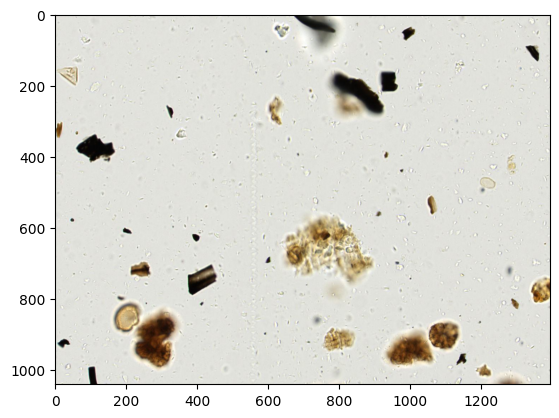

In [15]:
image = skimage.io.imread(os.path.join(valid_imgList[idx]))
print(image.shape)
plt.imshow(image)

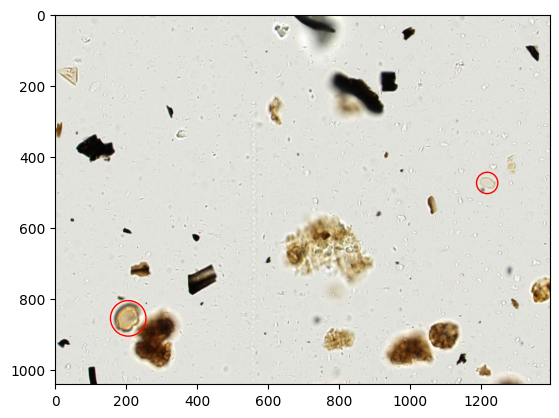

In [16]:
# Create a figure and axes
fig, ax = plt.subplots() #
plt.imshow(image)

for elm in valid_maskList[idx]:
    # Create a Circle patch object: center (x, y) and radius
    center_x = elm[3]
    center_y = elm[4]
    radius = elm[5]
    circle = patches.Circle((center_x, center_y), radius, color='r', fill=False) #
    ax.add_patch(circle) # Add the patch to the axes

plt.show()


# develop a helper function to create ground-truth for training deep learning models of pollen segmentation/detection.
The ground-truth is a distance transform map, measuring the distance from a pixel (within a pollen grain) to this grains circular boundary

In [17]:
# create a map of distance transform, measuring the distance from pollen gain center to its circular boundary

mask = image[:,:,0]*0
distTransformList = []

distTransformList = []
for elm in valid_maskList[idx]:
    # Create a Circle patch object: center (x, y) and radius
    center_x = elm[3]
    center_y = elm[4]
    radius = elm[5]

    mask_x, mask_y = np.asarray(range(mask.shape[1])).astype(np.float32), np.asarray(range(mask.shape[0])).astype(np.float32)
    mask_x, mask_y = np.meshgrid(mask_x, mask_y)
    mask_x = float(center_x) - mask_x
    mask_y = float(center_y) - mask_y

    tmpDistTransform = radius-np.sqrt(mask_x*mask_x + mask_y*mask_y)
    tmpDistTransform[tmpDistTransform<0]=0
    distTransformList += [tmpDistTransform]


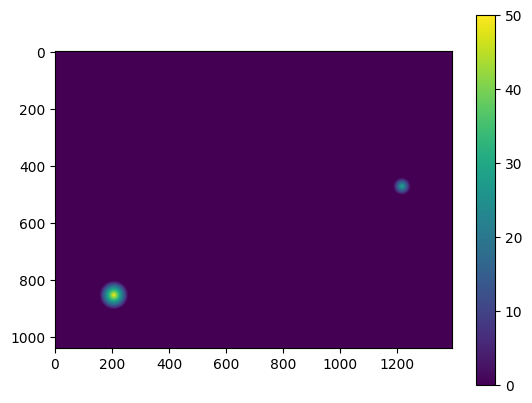

In [18]:
distTransform = np.stack(distTransformList)
distTransform = np.max(distTransform,0)

plt.imshow(distTransform)
plt.colorbar()

In [19]:
# let's make a function and use it later in the dataloader supporting deep learning
def makeDistanceTransformMask(maskSize, valid_maskList):
    distTransformList = []
    for elm in valid_maskList:
        # Create a Circle patch object: center (x, y) and radius
        center_x = elm[3]
        center_y = elm[4]
        radius = elm[5]

        mask_x, mask_y = np.asarray(range(mask.shape[1])).astype(np.float32), np.asarray(range(mask.shape[0])).astype(np.float32)
        mask_x, mask_y = np.meshgrid(mask_x, mask_y)
        mask_x = float(center_x) - mask_x
        mask_y = float(center_y) - mask_y

        tmpDistTransform = radius-np.sqrt(mask_x*mask_x + mask_y*mask_y)
        tmpDistTransform[tmpDistTransform<0]=0
        distTransformList += [tmpDistTransform]

    distTransform = np.stack(distTransformList)
    distTransform = np.max(distTransform,0)

    return distTransform

(1040, 1392) 50.0 0.0


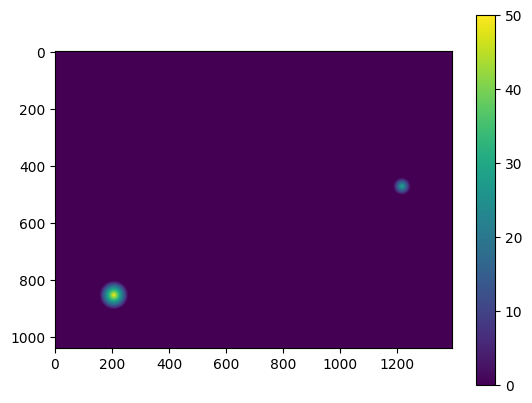

In [20]:
DistTransformMask = makeDistanceTransformMask(image.shape[:2], valid_maskList[idx])

print(DistTransformMask.shape, DistTransformMask.max(), DistTransformMask.min())

plt.imshow(DistTransformMask)
plt.colorbar()

# make a dataset class

In [21]:
class pollenDetectionDataset(Dataset):
    def __init__(self, imgList, maskList, transform=None, is_trainset=False):
        self.imgList = imgList
        self.maskList = maskList
        self.transform=transform
        self.current_set_len = len(imgList)
        self.is_trainset = is_trainset
        self.cropSize=[800,800]

    def __len__(self):
        return self.current_set_len

    def makeDistanceTransformMask(self, maskSize, valid_maskList):
        distTransformList = []
        for elm in valid_maskList:
            # Create a Circle patch object: center (x, y) and radius
            center_x = elm[3]
            center_y = elm[4]
            radius = elm[5]

            mask_x, mask_y = np.asarray(range(mask.shape[1])).astype(np.float32), np.asarray(range(mask.shape[0])).astype(np.float32)
            mask_x, mask_y = np.meshgrid(mask_x, mask_y)
            mask_x = float(center_x) - mask_x
            mask_y = float(center_y) - mask_y

            tmpDistTransform = radius-np.sqrt(mask_x*mask_x + mask_y*mask_y)
            tmpDistTransform[tmpDistTransform<0]=0
            distTransformList += [tmpDistTransform]
        if len(distTransformList)>1:
            distTransform = np.stack(distTransformList)
            distTransform = np.max(distTransform,0)
        else:
            distTransform = distTransformList[0]
        return distTransform


    def __getitem__(self, idx):
        cur_img = self.imgList[idx]
        cur_mask = self.maskList[idx]

        cur_img = skimage.io.imread(cur_img).astype(np.float32) / 255.0
        DistTransformMask = self.makeDistanceTransformMask(cur_img.shape[:2], cur_mask)

        cur_H, cur_W = cur_img.shape[:2]
        crop_topleft_h = cur_H - self.cropSize[0]
        crop_topleft_w = cur_W - self.cropSize[1]

        if self.is_trainset:
            crop_topleft_h = np.random.permutation(crop_topleft_h)[0]
            crop_topleft_w = np.random.permutation(crop_topleft_w)[0]
            cur_img = cur_img[crop_topleft_h:crop_topleft_h+self.cropSize[0],
                              crop_topleft_w:crop_topleft_w+self.cropSize[1],:]
            DistTransformMask = DistTransformMask[crop_topleft_h:crop_topleft_h+self.cropSize[0],
                                                  crop_topleft_w:crop_topleft_w+self.cropSize[1]]
        else:
            crop_topleft_h = np.random.permutation(crop_topleft_h)[0]
            crop_topleft_w = np.random.permutation(crop_topleft_w)[0]
            cur_img = cur_img[:self.cropSize[0], :self.cropSize[1], :]
            DistTransformMask = DistTransformMask[:self.cropSize[0], :self.cropSize[1]]

        if self.transform is not None:
            cur_img = self.transform(cur_img)

        binaryMask = copy.deepcopy(DistTransformMask)*0
        binaryMask[DistTransformMask>0] = 1

        return cur_img, DistTransformMask, binaryMask

In [22]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [23]:
# train_imgList = datasetInfo['train_imgList']
# train_maskList = datasetInfo['train_maskList']

trainset = pollenDetectionDataset(train_imgList,
                                  train_maskList,
                                  transform=data_transform,
                                  is_trainset=True
                                  )

valset = pollenDetectionDataset(valid_imgList,
                                valid_maskList,
                                transform=data_transform,
                                is_trainset=False
                                )

In [24]:
len(trainset), len(valset)

(169, 35)

In [25]:
batch_size = 4

dataloader_trainset = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
dataloader_valset = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

print(len(dataloader_trainset), len(dataloader_valset))

43 9


In [26]:
i = 0
for sample in dataloader_valset:
    i+=1
    if i%10==0:
        print(i)
        break
    cur_img, cur_disTransformMask, cur_binaryMask = sample
    cur_img = cur_img.to(device)
    cur_disTransformMask = cur_disTransformMask.to(device)
    cur_binaryMask = cur_binaryMask.to(device)

In [27]:
i = 0
for sample in dataloader_trainset:
    i+=1
    if i%10==0:
        print(i)
        break
    cur_img, cur_disTransformMask, cur_binaryMask = sample
    cur_img = cur_img.to(device)
    cur_disTransformMask = cur_disTransformMask.to(device)
    cur_binaryMask = cur_binaryMask.to(device)

10


In [28]:
cur_img.shape, cur_disTransformMask.shape, cur_binaryMask.shape

(torch.Size([4, 3, 800, 800]),
 torch.Size([4, 800, 800]),
 torch.Size([4, 800, 800]))

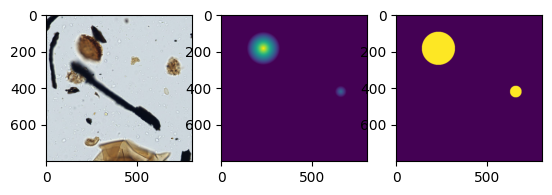

In [30]:
idx = 0
vis_img = cur_img[idx].permute(1,2,0).cpu().numpy()
vis_disTransformMask = cur_disTransformMask[idx].cpu().numpy()
vis_binaryMask = cur_binaryMask[idx].cpu().numpy()

plt.subplot(1, 3, 1) # 1 row, 2 columns, 1st plot
vis_img-=vis_img.min()
vis_img/=vis_img.max()
plt.imshow(vis_img)

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(vis_disTransformMask)


plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(vis_binaryMask)

# Let's design a model

In [31]:
class ConvBlock(nn.Module):
    """Layer to perform a convolution followed by ELU
    """
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()

        self.conv = Conv3x3(in_channels, out_channels)
        self.nonlin = nn.ELU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out = self.nonlin(out)
        return out

class Conv3x3(nn.Module):
    """Layer to pad and convolve input
    """
    def __init__(self, in_channels, out_channels, use_refl=True):
        super(Conv3x3, self).__init__()

        if use_refl:
            self.pad = nn.ReflectionPad2d(1)
        else:
            self.pad = nn.ZeroPad2d(1)
        self.conv = nn.Conv2d(int(in_channels), int(out_channels), 3)

    def forward(self, x):
        out = self.pad(x)
        out = self.conv(out)
        return out

def upsample(x):
    """Upsample input tensor by a factor of 2
    """
    return F.interpolate(x, scale_factor=2, mode="nearest")


class ResnetEncoder(nn.Module):
    """Pytorch module for a resnet encoder
    """
    def __init__(self, num_layers, pretrained):
        super(ResnetEncoder, self).__init__()
        self.path_to_model = './model'
        self.num_ch_enc = np.array([64, 64, 128, 256, 512])

        resnets = {18: models.resnet18, 34: models.resnet34, 50: models.resnet50,
                   101: models.resnet101, 152: models.resnet152}
        #resnets_pretrained_path = {18: 'resnet18-5c106cde.pth',
                                   #34: 'resnet34-333f7ec4.pth', 50: 'resnet50.pth', 101: 'resnet101.pth', 152: 'resnet152.pth'}


        if num_layers not in resnets:
            raise ValueError("{} is not a valid number of resnet layers".format(
                num_layers))

        self.encoder = resnets[num_layers]()

        if pretrained:
            print("using pretrained model")
            #self.encoder.load_state_dict(
                #torch.load(os.path.join(self.path_to_model, resnets_pretrained_path[num_layers])))
            checkpoint = torch.load(self.path_to_model)
            model.load_state_dict(checkpoint['model'])
            optimizer.load_state_dict(checkpoint['optimizer'])
            epoch = checkpoint['epoch']
            loss = checkpoint['loss']
            scheduler = checkpoint['lr_sched']

        if num_layers > 34:
            self.num_ch_enc[1:] *= 4

    def forward(self, input_image):
        self.features = []

        x = self.encoder.conv1(input_image)
        x = self.encoder.bn1(x)
        self.features.append(self.encoder.relu(x))
        self.features.append(
            self.encoder.layer1(self.encoder.maxpool(self.features[-1])))
        self.features.append(self.encoder.layer2(self.features[-1]))
        self.features.append(self.encoder.layer3(self.features[-1]))
        self.features.append(self.encoder.layer4(self.features[-1]))

        return self.features




class Decoder(nn.Module):
    def __init__(self, num_ch_enc, scaleList=(0, 1, 2, 3),
            num_output_channels=1, use_skips=True):
        super(Decoder, self).__init__()

        self.num_output_channels = num_output_channels
        self.use_skips = use_skips
        self.upsample_mode = 'nearest'
        self.scaleList = scaleList

        self.num_ch_enc = num_ch_enc
        self.num_ch_dec = np.array([16, 32, 64, 128, 256])

        # decoder
        self.convs = OrderedDict()
        for i in range(4, -1, -1):
            # upconv_0
            num_ch_in = self.num_ch_enc[-1] if i == 4 else self.num_ch_dec[i + 1]
            num_ch_out = self.num_ch_dec[i]
            self.convs[("upconv", i, 0)] = ConvBlock(num_ch_in, num_ch_out)

            # upconv_1
            num_ch_in = self.num_ch_dec[i]
            if self.use_skips and i > 0:
                num_ch_in += self.num_ch_enc[i - 1]
            num_ch_out = self.num_ch_dec[i]
            self.convs[("upconv", i, 1)] = ConvBlock(num_ch_in, num_ch_out)

        for s in self.scaleList:
            self.convs[("segMask", s)] = Conv3x3(self.num_ch_dec[s], 1)
            self.convs[("output", s)] = Conv3x3(self.num_ch_dec[s], self.num_output_channels)
            #self.convs[("outputAuxiliary", s)] = Conv3x3(self.num_ch_dec[s], self.num_output_channels)


        self.decoder = nn.ModuleList(list(self.convs.values()))
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, input_features):
        self.outputs = {}

        # decoder
        x = input_features[-1]
        for i in range(4, -1, -1):
            x = self.convs[("upconv", i, 0)](x)
            x = [upsample(x)]
            if self.use_skips and i > 0:
                x += [input_features[i - 1]]
            x = torch.cat(x, 1)
            x = self.convs[("upconv", i, 1)](x)
            if i in self.scaleList:
                self.outputs[("segMask", i)] = self.sigmoid(self.convs[("segMask", i)](x))
                self.outputs[("output", i)] = self.convs[("output", i)](x)

        return self.outputs

In [32]:
class PollenDet_SegDistTransform(nn.Module):
    def __init__(self, num_layers, scaleList=(0,1,2,3), pretrained=False):
        super(PollenDet_SegDistTransform, self).__init__()
        self.scaleList = scaleList
        self.encoder = ResnetEncoder(num_layers, pretrained)
        self.encoder.encoder.conv1 = nn.Conv2d(21, 64, (7, 7), (2, 2), (3, 3), bias=False) #added 10/07/21
        self.decoder = Decoder(self.encoder.num_ch_enc, scaleList=self.scaleList, num_output_channels=1)

    def forward(self, inputs1):
        inputs = (inputs1 )
        features = self.encoder(inputs)
        # for i in range(len(features)):
        #     print(features[i].shape)
        outputs = self.decoder(features)
        return outputs

In [33]:

scaleList = [0]           # the number of output layer for U-net


################## init model ###################
initModel = PollenDet_SegDistTransform(34, scaleList=scaleList, pretrained=False)
initModel.encoder.encoder.conv1 = nn.Conv2d(3, 64, (7, 7), (2, 2), (3, 3), bias=False) #change dimensions of the first layer in the encoder
initModel = initModel.to(device);

# # print(initModel.encoder.encoder)

In [34]:
output_masks = initModel(cur_img)
# cur_mask = cur_mask.to(device)

In [35]:
output_masks.keys()

dict_keys([('segMask', 0), ('output', 0)])

In [36]:
output_masks[("segMask", 0)].shape, output_masks[('output', 0)].shape

(torch.Size([4, 1, 800, 800]), torch.Size([4, 1, 800, 800]))